# Multiple Classification

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt

from keras import models, layers, optimizers, losses, metrics, regularizers
from keras.callbacks import History
from keras.datasets import reuters  # Reuters dataset
from keras.utils.np_utils import to_categorical

In [2]:
# get the 10,000 most frequently occurring words
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    # create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # set specific indices of results[i] to 1s
        results[i, sequence] = 1.0
    return results


# vectorize the training and test data

In [4]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels);

In [280]:
model: models.Sequential = models.Sequential()

# Input layer
# model.add(layers.Dense(46, activation='relu', input_shape=(10000,)))  # 64 hidden units
model.add(
    layers.Dense(
        46,
        activation="relu",
        input_shape=(10000,),
        kernel_regularizer=regularizers.l1_l2(l1=0.000001, l2=0.00001),
    )
)

# Hidden layers
model.add(layers.Dropout(0.3))
# model.add(layers.Dense(46, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)))
# add l2 regularization to the hidden layer
# model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))

# Output layer
model.add(layers.Dense(46, activation="softmax"))  # 46 output units
# Softmax activation - outputs a probability distribution over the 46 different output classes

In [281]:
model.compile(
    optimizer="rmsprop",  # optimizer function (rmsprop is usually a good choice for recurrent neural networks)
    loss="binary_crossentropy",  # loss function for categorical classification
    metrics=["accuracy"],  # fraction of correctly classified samples
)

In [282]:
# split the training data into a training and validation set
x_val = x_train[:1000]  # first 1000 samples
partial_x_train = x_train[1000:]  # rest of the samples

y_val = y_train[:1000]  # first 1000 labels
partial_y_train = y_train[1000:]  # rest of the labels

In [283]:
history: History = model.fit(  # train the model
    partial_x_train,  # training data
    partial_y_train,  # training labels
    epochs=32,  # number of epochs
    batch_size=512,  # batch size
    validation_data=(x_val, y_val),  # validation data
)

Epoch 1/32
16/16 [==============================] - 1s 16ms/step - loss: 0.5865 - accuracy: 0.1230 - val_loss: 0.4231 - val_accuracy: 0.2480
Epoch 2/32
16/16 [==============================] - 0s 10ms/step - loss: 0.3537 - accuracy: 0.1967 - val_loss: 0.2371 - val_accuracy: 0.3510
Epoch 3/32
16/16 [==============================] - 0s 10ms/step - loss: 0.2219 - accuracy: 0.2337 - val_loss: 0.1514 - val_accuracy: 0.3540
Epoch 4/32
16/16 [==============================] - 0s 10ms/step - loss: 0.1554 - accuracy: 0.2785 - val_loss: 0.1130 - val_accuracy: 0.3850
Epoch 5/32
16/16 [==============================] - 0s 10ms/step - loss: 0.1227 - accuracy: 0.3517 - val_loss: 0.0939 - val_accuracy: 0.4810
Epoch 6/32
16/16 [==============================] - 0s 10ms/step - loss: 0.1032 - accuracy: 0.4098 - val_loss: 0.0830 - val_accuracy: 0.5170
Epoch 7/32
16/16 [==============================] - 0s 10ms/step - loss: 0.0924 - accuracy: 0.4466 - val_loss: 0.0762 - val_accuracy: 0.5300
Epoch 8/32
16

In [90]:
def plot_model_loss(history: History, model_name: str) -> None:
    """
    Plot the training and validation loss

    ### Args:
    - history: history of the model
    - epochs: number of epochs
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(loss) + 1)  # number of epochs

    # plot the training and validation loss
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    plt.plot(epochs, loss, "o", label="Training loss")  # bo: blue dot
    plt.plot(epochs, val_loss, "--", label="Validation loss")  # b: blue line
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

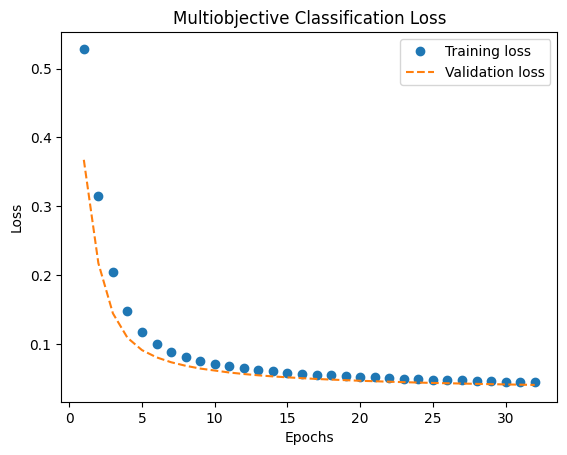

In [275]:
plot_model_loss(history, "Multiobjective Classification");

In [276]:
def plot_model_accuracy(history: History, model_name: str) -> None:
    """
    Plot the training and validation accuracy of the model
    """
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    epochs = range(1, len(acc) + 1)  # number of epochs

    # plot the training and validation accuracy
    plt.plot(epochs, acc, "o", label="Training accuracy")  # bo: blue dot
    plt.plot(epochs, val_acc, "--", label="Validation accuracy")  # b: blue line
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

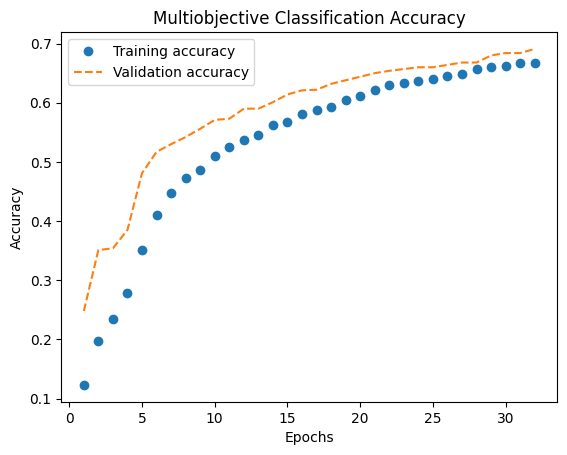

In [284]:
plot_model_accuracy(history, "Multiobjective Classification");

In [285]:
# evaluate the model on the test data
results = model.evaluate(x_test, y_test)

71/71 [==============================] - 0s 1ms/step - loss: 0.0491 - accuracy: 0.6790


In [84]:
# make some predictions
predictions = model.predict(x_test)

71/71 [==============================] - 0s 786us/step


In [193]:
sample: int = 0


for _ in range(7):
    _ = np.random.randint(0, len(x_test))
    # use random samples from the test set
    print(f"\nSample: {_}")
    # print(f'Probability dist: {predictions[sample]}')
    print(f"\tActual:     {np.argmax(y_test[_])}")
    print(f"\tPredicted:  {np.argmax(predictions[_])}", end="")

    # print on green if the prediction is correct, red otherwise
    if np.argmax(predictions[_]) == np.argmax(y_test[_]):
        print("\t\x1b[1;32;40mCorrect\x1b[0m")
    else:
        print("\t\x1b[1;31;40mIncorrect\x1b[0m")

    # do the same using a lambda function


# test the percentage of correct predictions
print(
    f"Percentage of correct predictions: {np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1)) / len(y_test)}"
)


Sample: 89
	Actual:     3
	Predicted:  3	Correct

Sample: 2133
	Actual:     20
	Predicted:  20	Correct

Sample: 141
	Actual:     3
	Predicted:  3	Correct

Sample: 923
	Actual:     3
	Predicted:  3	Correct

Sample: 1275
	Actual:     25
	Predicted:  16	Incorrect

Sample: 514
	Actual:     15
	Predicted:  11	Incorrect

Sample: 639
	Actual:     3
	Predicted:  3	Correct
Percentage of correct predictions: 0.7217275155832591
